# PyTorch digit classification — CPU

This notebook uses the same scikit-learn `digits` dataset as the previous project, but replaces the SVM with a small neural network built in PyTorch.

The goal is to understand the PyTorch training workflow: tensors, DataLoader, model definition, loss, optimizer, epochs, backpropagation, and evaluation.


In [16]:
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("PyTorch version:", torch.__version__)


PyTorch version: 2.14.0+cpu


## Load and inspect the dataset

Each handwritten digit is an `8 × 8` grayscale image. The flattened representation contains `64` numerical input features, and the target is one of the classes `0–9`.


In [17]:
digits = load_digits()

X = digits.data
y = digits.target

print("Images shape:", digits.images.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Classes:", digits.target_names)
print("Pixel range:", X.min(), "to", X.max())


Images shape: (1797, 8, 8)
Feature matrix shape: (1797, 64)
Target shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]
Pixel range: 0.0 to 16.0


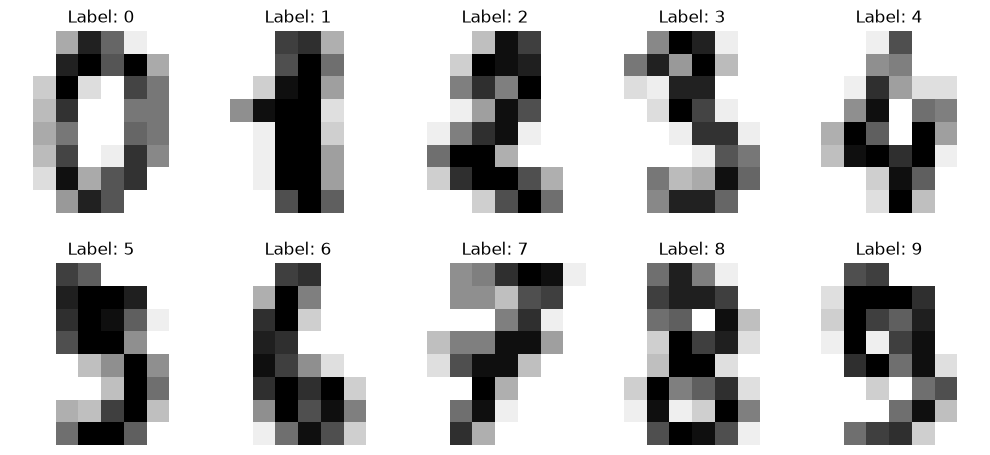

In [18]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for ax, image, label in zip(axes.ravel(), digits.images[:10], y[:10]):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Prepare the data

We use an `80/20` stratified train/test split. Pixel values are divided by `16` so that the inputs are approximately in the range `0–1`.

The NumPy arrays are then converted to PyTorch tensors. Training samples are provided to the model in small batches using a `DataLoader`.


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train = X_train / 16.0
X_test = X_test / 16.0

print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)


Training samples: (1437, 64)
Test samples: (360, 64)


In [20]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("X_train tensor:", X_train_tensor.shape, X_train_tensor.dtype)
print("y_train tensor:", y_train_tensor.shape, y_train_tensor.dtype)


X_train tensor: torch.Size([1437, 64]) torch.float32
y_train tensor: torch.Size([1437]) torch.int64


In [21]:
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

print("Number of training batches:", len(train_loader))


Number of training batches: 45


## Define and train the neural network

The network receives `64` pixel features, passes them through two hidden layers with ReLU activation, and produces `10` output scores — one for each digit.

We use cross-entropy loss and the Adam optimizer. This first version runs explicitly on the CPU.


In [22]:
device = torch.device("cpu")
print("Using device:", device)

class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)


model = DigitClassifier().to(device)

print(model)


Using device: cpu
DigitClassifier(
  (network): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)


Loss function: CrossEntropyLoss()
Optimizer: Adam


In [24]:
epochs = 100
loss_history = []

start_time = time.time()

for epoch in range(epochs):
    model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)

    print(
        f"Epoch {epoch + 1:02d}/{epochs} "
        f"- Loss: {epoch_loss:.4f}"
    )

training_time = time.time() - start_time

print(f"\nTraining time: {training_time:.2f} seconds")


Epoch 01/100 - Loss: 2.1106
Epoch 02/100 - Loss: 1.2217
Epoch 03/100 - Loss: 0.5548
Epoch 04/100 - Loss: 0.3553
Epoch 05/100 - Loss: 0.2585
Epoch 06/100 - Loss: 0.2145
Epoch 07/100 - Loss: 0.1758
Epoch 08/100 - Loss: 0.1555
Epoch 09/100 - Loss: 0.1347
Epoch 10/100 - Loss: 0.1175
Epoch 11/100 - Loss: 0.1086
Epoch 12/100 - Loss: 0.0930
Epoch 13/100 - Loss: 0.0844
Epoch 14/100 - Loss: 0.0774
Epoch 15/100 - Loss: 0.0712
Epoch 16/100 - Loss: 0.0683
Epoch 17/100 - Loss: 0.0610
Epoch 18/100 - Loss: 0.0594
Epoch 19/100 - Loss: 0.0493
Epoch 20/100 - Loss: 0.0462
Epoch 21/100 - Loss: 0.0443
Epoch 22/100 - Loss: 0.0389
Epoch 23/100 - Loss: 0.0366
Epoch 24/100 - Loss: 0.0344
Epoch 25/100 - Loss: 0.0319
Epoch 26/100 - Loss: 0.0298
Epoch 27/100 - Loss: 0.0258
Epoch 28/100 - Loss: 0.0255
Epoch 29/100 - Loss: 0.0227
Epoch 30/100 - Loss: 0.0209
Epoch 31/100 - Loss: 0.0206
Epoch 32/100 - Loss: 0.0192
Epoch 33/100 - Loss: 0.0192
Epoch 34/100 - Loss: 0.0168
Epoch 35/100 - Loss: 0.0160
Epoch 36/100 - Loss:

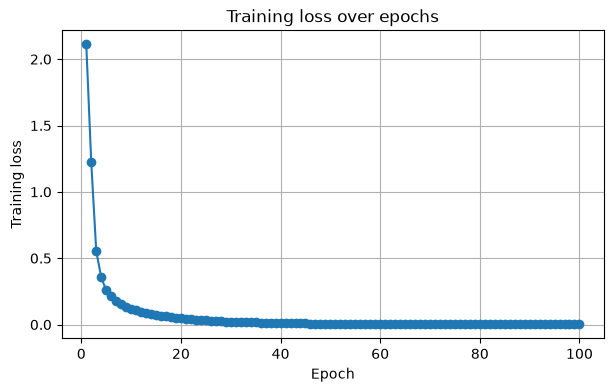

In [25]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training loss over epochs")
plt.grid(True)

plt.show()


## Evaluate the trained model

During evaluation, gradients are disabled because the model is no longer learning. The network produces ten output scores for each image, and the class with the highest score becomes the prediction.

We then use the same scikit-learn metrics from the previous project so that the PyTorch model can be evaluated in a familiar way.


In [26]:
model.eval()

with torch.no_grad():
    X_test_device = X_test_tensor.to(device)

    outputs = model(X_test_device)

    predicted = torch.argmax(outputs, dim=1)

predicted_np = predicted.cpu().numpy()

print("First 20 predictions:")
print(predicted_np[:20])

print("\nFirst 20 actual labels:")
print(y_test[:20])


First 20 predictions:
[5 2 8 1 7 2 6 2 6 5 0 5 9 3 4 4 2 4 4 9]

First 20 actual labels:
[5 2 8 1 7 2 6 2 6 5 0 5 9 3 4 4 2 4 9 9]


In [27]:
accuracy = accuracy_score(y_test, predicted_np)

print(f"Test accuracy: {accuracy:.4f}")
print(f"Test accuracy: {accuracy * 100:.2f}%")


Test accuracy: 0.9806
Test accuracy: 98.06%


In [28]:
print(
    classification_report(
        y_test,
        predicted_np
    )
)


              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.95      0.97      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      1.00      0.97        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       0.97      1.00      0.99        36
           8       0.94      0.94      0.94        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



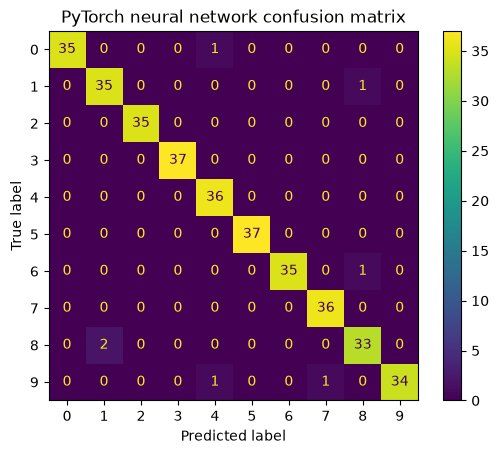

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predicted_np
)

plt.title("PyTorch neural network confusion matrix")
plt.show()


## Inspect misclassified images

Looking at incorrect predictions helps connect the numerical evaluation metrics to the actual handwritten samples that were difficult for the model.


Number of misclassified samples: 7


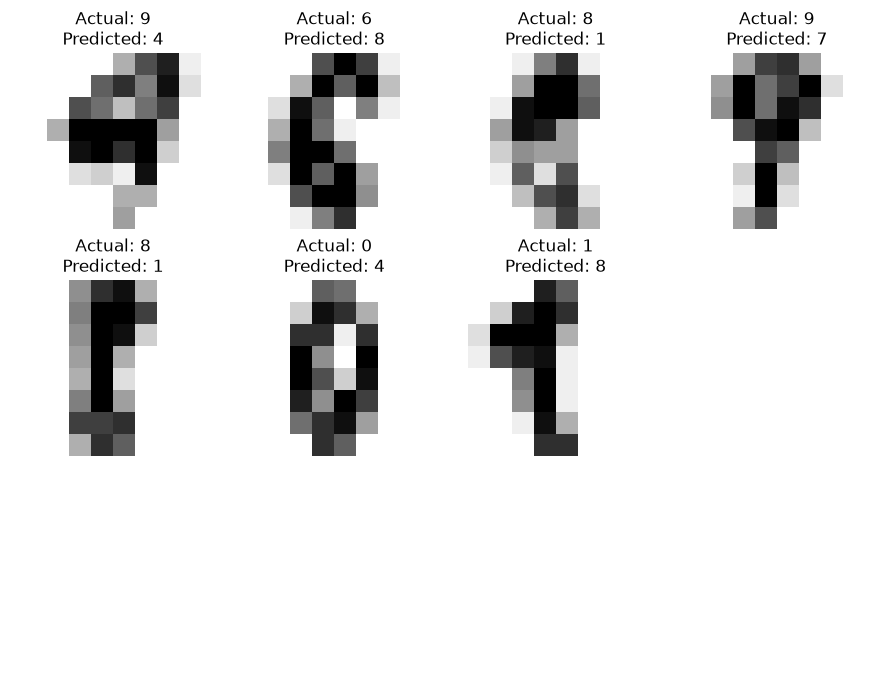

In [30]:
wrong_indices = np.where(predicted_np != y_test)[0]

print("Number of misclassified samples:", len(wrong_indices))

num_to_show = min(12, len(wrong_indices))

fig, axes = plt.subplots(3, 4, figsize=(9, 7))

for ax, idx in zip(axes.ravel(), wrong_indices[:num_to_show]):
    ax.imshow(
        X_test[idx].reshape(8, 8),
        cmap="gray_r"
    )

    ax.set_title(
        f"Actual: {y_test[idx]}\n"
        f"Predicted: {predicted_np[idx]}"
    )

    ax.axis("off")

for ax in axes.ravel()[num_to_show:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## Summary

This notebook introduced the core PyTorch workflow:

`data → tensors → batches → neural network → forward pass → loss → backpropagation → optimizer update → evaluation`

The next version can keep the same model and dataset but move the computation to an NVIDIA GPU, making it easy to compare CPU and GPU execution.
